In [1]:
import os, sys
import numpy as np
import cv2
import matplotlib.pyplot as plt
from glob import glob
from IPython.display import Image, display as ipy_display

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)
os.chdir(PROJECT_ROOT)

from evals.eval_core import nll_gauss2d, entropy2d
from utilities.utils import load_houseexpo_image_as_grid

SIGMA_CAP = 250.0
RESULTS   = "results"


# ── per-episode helpers ───────────────────────────────────────────

def per_target_metrics(npz_path, sigma_cap=SIGMA_CAP):
    data = np.load(npz_path, allow_pickle=True)
    mu = np.asarray(data["mu"],         dtype=float)   # (T, K, 2)
    S  = np.asarray(data["Sigma"],      dtype=float)   # (T, K, 2, 2)
    x  = np.asarray(data["x_true"],     dtype=float)   # (T, K, 2)
    E  = (np.asarray(data["exist_mask"]) > 0)          # (T, K)
    T, K, _ = mu.shape
    valid = np.isfinite(x).all(axis=-1) & np.isfinite(mu).all(axis=-1)
    results = []
    for k in range(K):
        mask = E[:, k] & valid[:, k]
        n = int(mask.sum())
        if n == 0:
            continue
        se_k   = ((x[mask, k, :] - mu[mask, k, :]) ** 2).sum(axis=-1)
        rmse_k = float(np.sqrt(se_k.mean()))
        nll_k = ent_k = 0.0
        for t in np.where(mask)[0]:
            nll_k += nll_gauss2d(x[t, k], mu[t, k], S[t, k], sigma_cap=sigma_cap)
            ent_k += entropy2d(S[t, k], sigma_cap=sigma_cap)
        results.append({"rmse": rmse_k, "nll": nll_k / n, "entropy": ent_k / n})
    return results


def collect_per_target(ts_dirs):
    all_targets = []
    for d in sorted(ts_dirs):
        if not os.path.isdir(d):
            continue
        for npz_path in sorted(glob(os.path.join(d, "*.npz"))):
            if os.path.getsize(npz_path) == 0:
                continue
            try:
                all_targets.extend(per_target_metrics(npz_path))
            except Exception as e:
                print(f"[WARN] {npz_path}: {e}")
    return all_targets


# ── figure helpers ────────────────────────────────────────────────

def per_step_nll(mu, S, x_true, exist_mask, sigma_cap=SIGMA_CAP):
    """Per-timestep NLL averaged over existing targets. t=0 is spawn state."""
    mu = np.asarray(mu,          dtype=float)
    S  = np.asarray(S,           dtype=float)
    x  = np.asarray(x_true,      dtype=float)
    E  = np.asarray(exist_mask) > 0
    T  = mu.shape[0]
    nll_t = np.full(T, np.nan)
    for t in range(T):
        mask_t = E[t] & np.isfinite(x[t]).all(-1) & np.isfinite(mu[t]).all(-1)
        if not mask_t.any():
            continue
        vals = [nll_gauss2d(x[t, k], mu[t, k], S[t, k], sigma_cap=sigma_cap)
                for k in np.where(mask_t)[0]]
        nll_t[t] = float(np.mean(vals))
    return nll_t


def moving_average_nan_safe(arr, w):
    arr = np.asarray(arr, dtype=float)
    if w <= 1:
        return arr
    out = np.full_like(arr, np.nan)
    for i in range(len(arr)):
        window = arr[max(0, i - w + 1):i + 1]
        valid  = window[np.isfinite(window)]
        if len(valid):
            out[i] = valid.mean()
    return out


def load_robot_traj(npz_path, label=""):
    with np.load(npz_path, allow_pickle=True) as d:
        if "robot" in d:
            return np.asarray(d["robot"])
    print(f"[WARN] no 'robot' key in {npz_path}")
    return None


def plot_snapshot_ax(ax, map_img, robot_traj, x_true, exist_mask, t_snap, color):
    """Plot one snapshot: map bg + robot path up to t_snap + target positions."""
    ax.imshow(map_img, cmap="gray", origin="upper", vmin=0, vmax=1)
    ax.invert_yaxis()
    ax.axis("off")
    if robot_traj is not None and len(robot_traj) > 1:
        t_end = min(t_snap + 1, len(robot_traj))
        ax.plot(robot_traj[:t_end, 0], robot_traj[:t_end, 1],
                color=color, lw=1.5, alpha=0.85, zorder=3)
        t_r = min(t_snap, len(robot_traj) - 1)
        ax.scatter(robot_traj[t_r, 0], robot_traj[t_r, 1],
                   s=60, color=color, zorder=5)
    if t_snap < x_true.shape[0]:
        for k in range(x_true.shape[1]):
            if exist_mask[t_snap, k]:
                ax.scatter(x_true[t_snap, k, 0], x_true[t_snap, k, 1],
                           s=60, marker="x", color="red", linewidths=2, zorder=6)


print(f"Project root: {PROJECT_ROOT}")
print("Ready.")

Project root: /Users/liusaida/Desktop/MATT-Diff
Ready.


In [ ]:
#   results/dp_simple/timeseries/         dp_ep000.npz ... dp_ep019.npz
#   results/dp_no_map_simple/timeseries/  dp_ep000.npz ... dp_ep019.npz
#   results/bc_simple/timeseries/         bc_ep000.npz ... bc_ep019.npz
#   results/dqn_simple/timeseries/        dqn_ep000.npz ... dqn_ep019.npz
#   results/timeseries_track/             track_ep000.npz ... track_ep019.npz
#   results/timeseries_reacq/             reacq_ep000.npz ... reacq_ep019.npz
#   results/timeseries_frontier/          frontier_ep000.npz ... frontier_ep019.npz

CC_METHODS = ["DP", "DP no-map", "BC", "DQN", "Track", "Reacq", "Frontier"]

METHOD_DIRS = {
    "DP":        [f"{RESULTS}/dp_simple/timeseries"],
    "DP no-map": [f"{RESULTS}/dp_no_map_simple/timeseries"],
    "BC":        [f"{RESULTS}/bc_simple/timeseries"],
    "DQN":       [f"{RESULTS}/dqn_simple/timeseries"],
    "Track":     [f"{RESULTS}/timeseries_track"],
    "Reacq":     [f"{RESULTS}/timeseries_reacq"],
    "Frontier":  [f"{RESULTS}/timeseries_frontier"],
}

rows = []
for method in CC_METHODS:
    targets = collect_per_target(METHOD_DIRS[method])
    if not targets:
        rows.append({"Method": method, "N": 0, "RMSE": "--", "NLL": "--", "Entropy": "--"})
        continue
    rmses = np.array([t["rmse"] for t in targets])
    nlls  = np.array([t["nll"]  for t in targets])
    ents  = np.array([t["entropy"] for t in targets])
    rows.append({
        "Method":  method,
        "N":       len(targets),
        "RMSE":    f"{rmses.mean():.3f} ± {rmses.std():.3f}",
        "NLL":     f"{nlls.mean():.3f} ± {nlls.std():.3f}",
        "Entropy": f"{ents.mean():.3f} ± {ents.std():.3f}",
    })

print("=" * 70)
print("  evaluation_map — collision_freeze — combined (seeds 57–76)")
print("=" * 70)
print(f"{'Method':<12} {'N':>5}  {'RMSE':^22}  {'NLL':^22}  {'Entropy':^22}")
print("-" * 70)
for r in rows:
    print(f"{r['Method']:<12} {r['N']:>5}  {r['RMSE']:^22}  {r['NLL']:^22}  {r['Entropy']:^22}")

  evaluation_map — collision_freeze — combined (seeds 57–76)
Method           N           RMSE                    NLL                   Entropy        
----------------------------------------------------------------------
DP              84    268.840 ± 155.540         13.124 ± 1.468          13.332 ± 1.017    
DP no-map       84    273.525 ± 148.701         13.295 ± 1.321          13.501 ± 0.911    
BC              84    299.776 ± 133.638         13.464 ± 1.351          13.582 ± 1.014    
DQN             84    297.049 ± 134.074         13.335 ± 1.878          13.465 ± 1.589    
Track           84    259.882 ± 156.856         12.458 ± 2.357          12.700 ± 1.890    
Reacq           84    267.100 ± 152.533         12.712 ± 2.063          12.934 ± 1.610    
Frontier        84    259.133 ± 161.133         12.581 ± 2.045          12.813 ± 1.531    


In [ ]:
# ── shared constants for figure cells ────────────────────────────
MAP_PATH   = os.path.join(PROJECT_ROOT, "map", "evaluation_map.png")
TMAX       = 1000
EP_SEED    = 18      

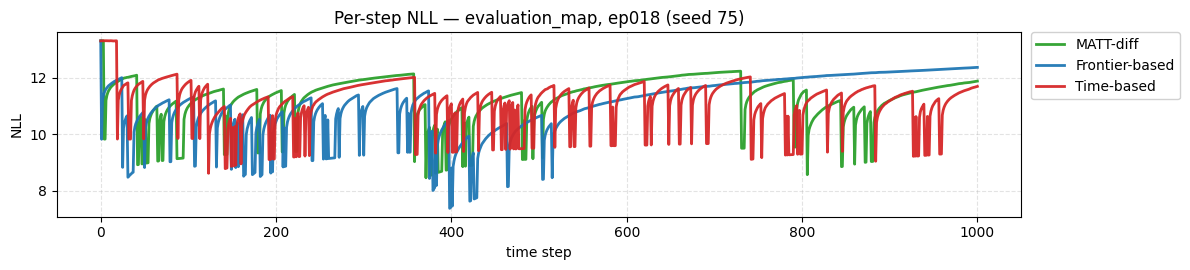

In [4]:
# Per-step NLL curve: DP vs Frontier vs Track (ep018 / seed 75)
PLANNER_COLORS = {
    "MATT-diff":         "#2ca02c",
    "Frontier-based":    "#1f77b4",
    "Uncertainty-based": "#9467bd",
    "Time-based":        "#d62728",
}

NPZ_SPECS = [
    (f"{RESULTS}/dp_simple/timeseries/dp_ep{EP_SEED:03d}.npz",       "MATT-diff"),
    (f"{RESULTS}/timeseries_frontier/frontier_ep{EP_SEED:03d}.npz",  "Frontier-based"),
    (f"{RESULTS}/timeseries_track/track_ep{EP_SEED:03d}.npz",        "Time-based"),
]

fig, ax = plt.subplots(figsize=(12, 2.8))
for path, label in NPZ_SPECS:
    if not os.path.exists(path):
        print(f"[WARN] missing: {path}"); continue
    with np.load(path, allow_pickle=True) as d:
        nll = per_step_nll(d["mu"], d["Sigma"], d["x_true"], d["exist_mask"])
    t = np.arange(len(nll))
    y = moving_average_nan_safe(nll, 1)
    ax.plot(t, y, label=label, color=PLANNER_COLORS.get(label, "#7f7f0f"), lw=2.0, alpha=0.95)

ax.set_xlabel("time step")
ax.set_ylabel("NLL")
ax.set_title(f"Per-step NLL — evaluation_map, ep{EP_SEED:03d} (seed {57 + EP_SEED})")
ax.grid(alpha=0.35, linestyle="--")
ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1), borderaxespad=0, framealpha=0.9)
plt.tight_layout()
plt.show()

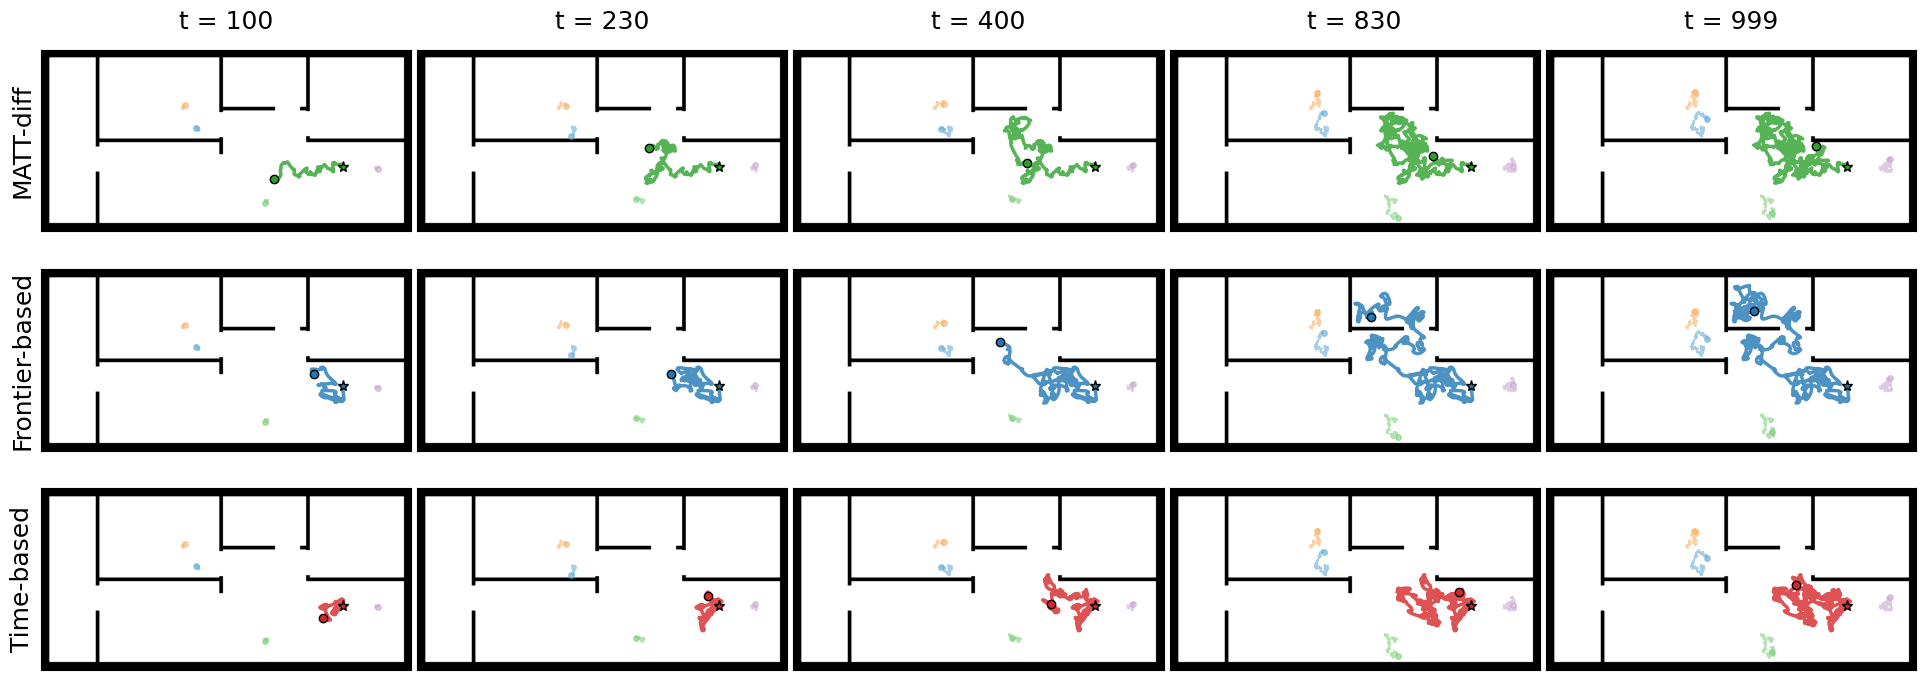

In [7]:
TARGET_COLORS = ["#6aaed6","#f8b36a","#7ecf7a","#c9a8cf","#ef6f6a",
                 "#94cfca","#ffb8c0","#b69b7e","#cfc9c4","#f0d463"]
TARGET_LS = (0, (4, 3))     # dashed
TARGET_LW = 1.3
TARGET_ALPHA = 0.6

map_img = load_houseexpo_image_as_grid(MAP_PATH)
H, W = map_img.shape # Needed for setting extent and axis limits

with np.load(FILES_TO_PLOT[0]["filepath"], allow_pickle=True) as d:
    x_true_ref     = np.asarray(d["x_true"], np.float32)[:TMAX]
    exist_mask_ref = (np.asarray(d["exist_mask"]).astype(bool)[:x_true_ref.shape[0]]
                      if "exist_mask" in d
                      else np.isfinite(x_true_ref[..., :2]).all(-1))

n_planners = len(FILES_TO_PLOT)
n_snaps    = len(FILES_TO_PLOT[0]["t_snapshots"])
fig, axes  = plt.subplots(n_planners, n_snaps,
                           figsize=(n_snaps * 4.5, n_planners * 2.4),
                           squeeze=False)

for i, item in enumerate(FILES_TO_PLOT):
    if not os.path.exists(item["filepath"]):
        print(f"[SKIP] {item['filepath']}"); continue
    robot_traj = load_robot_traj(item["filepath"], item["label"])
    T_run = min(len(robot_traj) if robot_traj is not None else TMAX,
                x_true_ref.shape[0]) - 1
    
    for j, t_snap in enumerate(item["t_snapshots"]):
        ax     = axes[i, j]
        t_snap = min(t_snap, T_run)
        
        if i == 0:
            ax.set_title(f"t = {t_snap}", fontsize=18, pad=15)
        if j == 0:
            ax.set_ylabel(item["label"], fontsize=18, labelpad=5, rotation=90)

        # 1) Map display (Wall=Black, Floor=White)
        ax.imshow(1 - map_img, cmap='gray_r', extent=[0, W, H, 0], vmin=0, vmax=1)

        # 2) Draw target trajectories and current positions
        for k in range(x_true_ref.shape[1]):
            col = TARGET_COLORS[k % len(TARGET_COLORS)]
            t_end = min(t_snap + 1, x_true_ref.shape[0])
            mask = exist_mask_ref[:t_end, k]
            txy  = x_true_ref[:t_end][mask, k, :2]
            
            # Draw trajectory
            if len(txy) >= 2:
                ax.plot(txy[:, 0], txy[:, 1], color=col, linestyle=TARGET_LS, 
                        linewidth=TARGET_LW, alpha=TARGET_ALPHA, zorder=6)
            
            # Draw current position
            if exist_mask_ref[t_snap, k]:
                ax.plot(x_true_ref[t_snap, k, 0], x_true_ref[t_snap, k, 1],
                        marker='.', markersize=8, color=col, markeredgecolor=col, 
                        linestyle='None', zorder=7, alpha=TARGET_ALPHA)

        # 3) Robot trajectory (0..t_snap)
        if robot_traj is not None and len(robot_traj) > 0:
            t_end = min(t_snap + 1, len(robot_traj))
            ax.plot(robot_traj[:t_end, 0], robot_traj[:t_end, 1],
                    color=item["color"], alpha=0.8, linewidth=2.5, zorder=8)
            
            t_r = min(t_snap, len(robot_traj) - 1)
            
            # 5) Robot start position
            ax.plot(robot_traj[0, 0], robot_traj[0, 1],
                    marker='*', color=item["color"], markersize=8, 
                    markeredgecolor='k', mew=1.0, linestyle='None', zorder=9)

            # 4) Robot current position
            ax.plot(robot_traj[t_r, 0], robot_traj[t_r, 1],
                    marker='o', color=item["color"], markersize=6, 
                    markeredgecolor='k', mew=1.0, linestyle='None', zorder=10)

        # 6) Decorations
        ax.set_aspect('equal')
        ax.set_xlim(0, W)
        ax.set_ylim(H, 0)
        ax.tick_params(axis='both', which='both', bottom=False, top=False, 
                       left=False, right=False, labelbottom=False, labelleft=False)

# Adjustment to remove gap between title and figures
plt.tight_layout(h_pad=-4.0, w_pad=0.5)
fig.subplots_adjust(left=0.16, hspace=0.0)
plt.show()